In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred))
    )

def mase(y_true, y_pred, y_train):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_train = np.array(y_train)

    naive_error = np.mean(np.abs(np.diff(y_train)))
    return np.mean(np.abs(y_true - y_pred)) / naive_error

def theil_u(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    denominator = np.sqrt(np.mean(y_true ** 2) + np.mean(y_pred ** 2))
    u = rmse / denominator
    return u

# Load data
df = pd.read_excel('output_week.xlsx')

# Count occurrences and sort by week
data = df['WEEK'].value_counts().reset_index()
data.columns = ['WEEK', 'DATA']

# Convert week to a date representing the beginning of the week
data['WEEK_period'] = pd.to_datetime(
    data['WEEK'] + '-1',
    format='%G-%V-%u',
    errors='coerce'
)
data = data.sort_values('WEEK_period').reset_index(drop=True)

# ------------------------------
# Smoothing (moving average)
# ------------------------------
data['DATA_smooth'] = data['DATA'].rolling(window=5, center=True).mean()
data['DATA_smooth'].fillna(method='bfill', inplace=True)
data['DATA_smooth'].fillna(method='ffill', inplace=True)

# Data normalization
scaler = MinMaxScaler(feature_range=(0.1, 1))
data['y'] = scaler.fit_transform(data[['DATA_smooth']])

# ------------------------------
# Create lag variables
# ------------------------------
n_lags = 11  # You may test 12, 16, or 26 lags

for i in range(1, n_lags + 1):
    data[f'lag_{i}'] = data['y'].shift(i)

data = data.dropna().reset_index(drop=True)

# ------------------------------
# Prepare X and y
# ------------------------------
lag_cols = [f'lag_{i}' for i in range(n_lags, 0, -1)]

X = data[lag_cols].values.astype(np.float32)
y = data['y'].values.astype(np.float32)

# ------------------------------
# Train/Test Split
# ------------------------------
split = int(len(X) * 0.7)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

/var/folders/36/lb3mdhtj2lldbybnz877q_hr0000gn/T/ipykernel_2979/1350415025.py:54: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['DATA_smooth'].fillna(method='bfill', inplace=True)
/var/folders/36/lb3mdhtj2lldbybnz877q_hr0000gn/T/ipykernel_2979/1350415025.py:54: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['DATA_smooth'].fillna(method='bfill', inplace=True)
/var/folders/36/lb3mdhtj2lldbybnz877q_hr0000gn/T/ipykernel_2979/135041502

/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  
RMSE: 0.0285
R²: 0.8706
MAPE (normalized): 11.23%
MAPE (original scale): 9.18%
sMAPE: 10.71%
MASE: 0.7049
Theil's U1: 0.078129485
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 484us/step


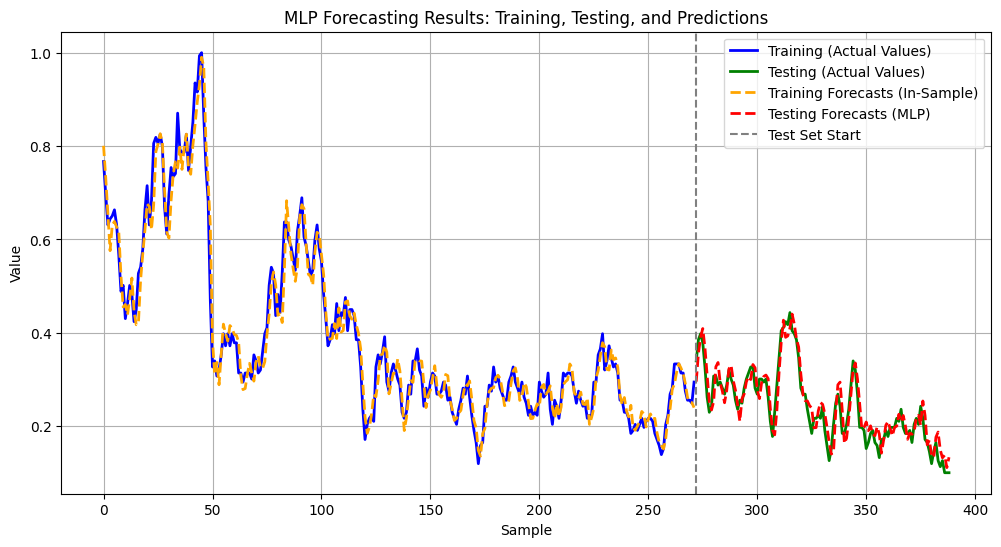

In [4]:
# ------------------------------
# Create MLP Model
# ------------------------------
model = Sequential()

# First hidden layer
model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))

# Second hidden layer
model.add(Dense(64, activation='relu'))

# Output layer
model.add(Dense(1))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

# ------------------------------
# Training with Early Stopping
# ------------------------------
early = EarlyStopping(
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early],
    verbose=0
)

# ------------------------------
# Forecasting
# ------------------------------
y_pred = model.predict(X_test).flatten()

# ------------------------------
# Evaluation Metrics
# ------------------------------
smape_value = smape(y_test, y_pred)
mase_value = mase(y_test, y_pred, y_train)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Normalized MAPE
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# MAPE on the original scale
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_real = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()

mape_real = np.mean(
    np.abs((y_test_real - y_pred_real) / y_test_real)
) * 100

u1 = theil_u(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAPE (normalized): {mape:.2f}%")
print(f"MAPE (original scale): {mape_real:.2f}%")
print(f"sMAPE: {smape_value:.2f}%")
print(f"MASE: {mase_value:.4f}")
print("Theil's U1:", u1)

y_pred_train = model.predict(X_train)

plt.figure(figsize=(12, 6))

# Indices
idx_train = np.arange(len(y_train))
idx_test = np.arange(len(y_train), len(y_train) + len(y_test))

# ---------------------------
# ACTUAL VALUES
# ---------------------------

# Training actual values
plt.plot(
    idx_train,
    y_train,
    label='Training (Actual Values)',
    color='blue',
    linewidth=2
)

# Testing actual values
plt.plot(
    idx_test,
    y_test,
    label='Testing (Actual Values)',
    color='green',
    linewidth=2
)

# ---------------------------
# FORECASTS
# ---------------------------

# In-sample forecasts
plt.plot(
    idx_train,
    y_pred_train,
    label='Training Forecasts (In-Sample)',
    color='orange',
    linestyle='--',
    linewidth=2
)

# Out-of-sample forecasts
plt.plot(
    idx_test,
    y_pred,
    label='Testing Forecasts (MLP)',
    color='red',
    linestyle='--',
    linewidth=2
)

# ---------------------------
# TRAIN/TEST SPLIT LINE
# ---------------------------

plt.axvline(
    x=len(y_train),
    color='gray',
    linestyle='--',
    label='Test Set Start'
)

plt.title('MLP Forecasting Results: Training, Testing, and Predictions')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
#Hyperparameter optimization was performed using a Random Search strategy.

def criar_mlp(num_layers, units, dropout, input_dim):

    model = Sequential()

    for i in range(num_layers):

        model.add(Dense(units, activation='relu', input_dim=input_dim if i == 0 else None))

        if dropout > 0:
            model.add(Dropout(dropout))

    model.add(Dense(1))  # saída regressão

    return model

def treinar_e_validar_mlp(model, X_tr, y_tr, X_val, y_val, lr, batch_size):

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='mse'
    )

    model.fit(
        X_tr,
        y_tr,
        epochs=50,
        batch_size=batch_size,
        verbose=0
    )

    pred = model.predict(X_val).flatten()

    rmse = np.sqrt(mean_squared_error(y_val, pred))

    return rmse

from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    shuffle=False  # importante para séries temporais
)

param_space = {
    "num_layers": [1, 2, 3],
    "units": [32, 64, 128, 256],
    "dropout": [0.0, 0.1, 0.2, 0.3],
    "lr": [1e-4, 5e-4, 1e-3],
    "batch_size": [16, 32, 64]
}

from sklearn.model_selection import ParameterSampler

configs = list(
    ParameterSampler(
        param_space,
        n_iter=20,
        random_state=42
    )
)

best_loss = float("inf")
best_params = None

for params in configs:

    model = criar_mlp(
        num_layers=params["num_layers"],
        units=params["units"],
        dropout=params["dropout"],
        input_dim=X_train.shape[1]
    )

    loss = treinar_e_validar_mlp(
        model,
        X_tr,
        y_tr,
        X_val,
        y_val,
        lr=params["lr"],
        batch_size=params["batch_size"]
    )

    print(loss, params)

    if loss < best_loss:
        best_loss = loss
        best_params = params

print("Melhores parâmetros:", best_params)

/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
0.03796689674579777 {'units': 32, 'num_layers': 2, 'lr': 0.001, 'dropout': 0.3, 'batch_size': 64}


/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/stepWARNING:tensorflow:5 out of the last 14 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x168d80940> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
0.0374046300084731 {'units': 256, 'num_layers': 1, 'lr': 0.0001, 'dropout': 0.2, 'batch_size': 16}


/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
0.07012611759985822 {'units': 32, 'num_layers': 1, 'lr': 0.0001, 'dropout': 0.2, 'batch_size': 16}


/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
0.02797628755002919 {'units': 64, 'num_layers': 3, 'lr': 0.0001, 'dropout': 0.0, 'batch_size': 16}


/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
0.038777451282754456 {'units': 32, 'num_layers': 2, 'lr': 0.001, 'dropout': 0.3, 'batch_size': 32}
Melhores parâmetros: {'units': 128, 'num_layers': 2, 'lr': 0.001, 'dropout': 0.0, 'batch_size': 16}
